In [2]:
pip install realesrgan

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 20.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 28.0 MB/s eta 0:00:00
  Created wheel for basicsr: filename=basicsr-1.4.2-py3-none-any.whl size=214817 sha256=e7b3bc67b81de0200b50a6180e913b5e5810d1e2143d5902842af38b87f8c8d8
  Stored in directory: /root/.cache/pip/wheels/9a/e3/e4/58f29bfabb622dd40b6d9839318ce5bf092062b81ca3aa19ea
  Created wheel for 

In [3]:
pip install super-image pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.9/95.9 kB 5.9 MB/s eta 0:00:00


In [5]:
pip install pytorch-pretrained-biggan torch scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 11.4 MB/s eta 0:00:00


Инициализация моделей BigGAN и Super-Resolution (PAN)...


100%|██████████| 715/715 [00:00<00:00, 2193802.02B/s]


config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

pytorch_model_4x.pt:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

https://huggingface.co/eugenesiow/pan/resolve/main/pytorch_model_4x.pt
Генерация и улучшение варианта 1...
Генерация и улучшение варианта 2...
Генерация и улучшение варианта 3...
Генерация и улучшение варианта 4...


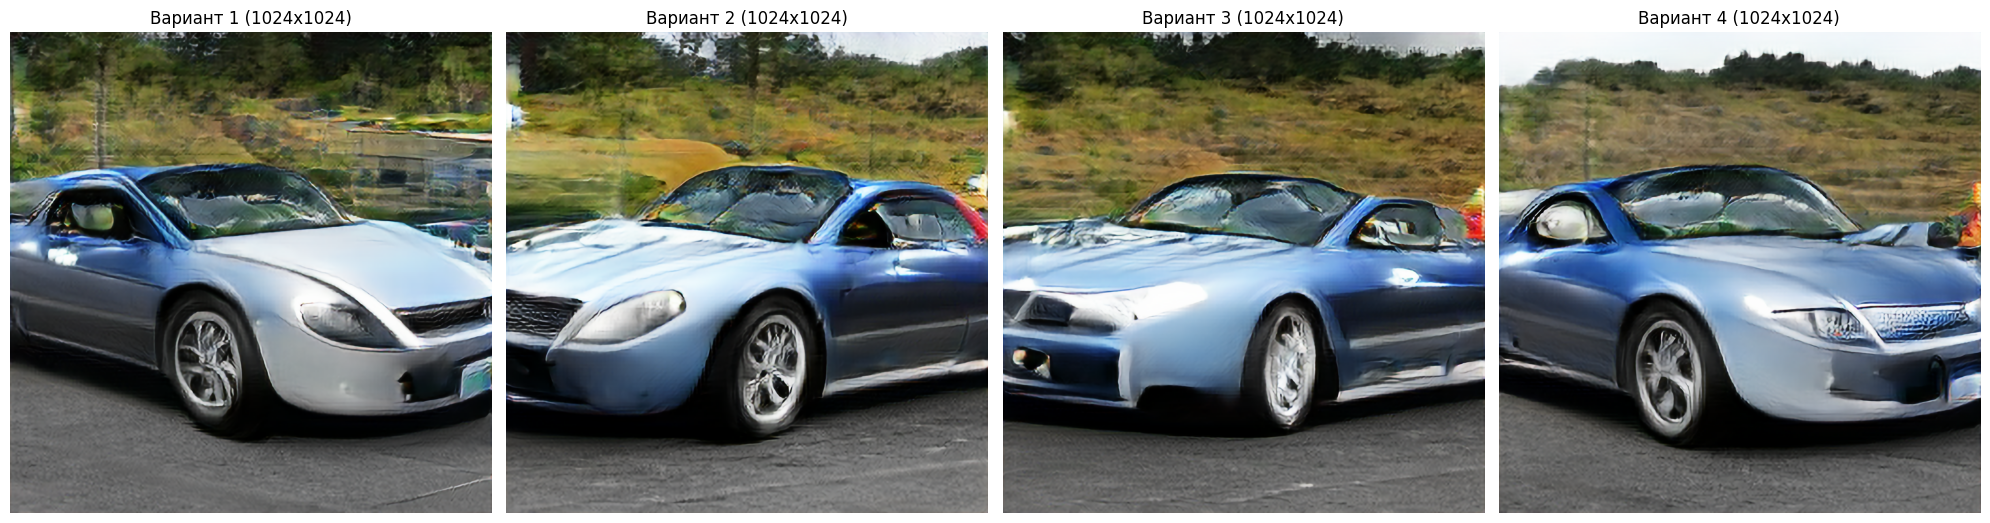

Очистка ресурсов видеокарты...


In [6]:
import gc
import torch
from pytorch_pretrained_biggan import BigGAN, truncated_noise_sample
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Импортируем только саму модель и загрузчик
from super_image import PanModel, ImageLoader

# 1. Принудительная очистка перед стартом
gc.collect()
torch.cuda.empty_cache()

# 2. Настройки генерации
car_class_index = 817  # Код класса "sports car" в ImageNet
truncation_value = 0.15
num_images = 4

# Создаем область для вывода картинок
fig, axes = plt.subplots(1, num_images, figsize=(20, 6))
print("Инициализация моделей BigGAN и Super-Resolution (PAN)...")

try:
    # 3. Инициализация BigGAN
    model = BigGAN.from_pretrained('biggan-deep-256')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()

    # 4. Инициализация апскейлера PAN (Scale x4)
    model_sr = PanModel.from_pretrained('eugenesiow/pan', scale=4)
    model_sr.to(device)
    model_sr.eval()

    # Формируем целевой класс y (1, 1000)
    y_one_hot = np.zeros((1, 1000), dtype=np.float32)
    y_one_hot[0, car_class_index] = 1.0
    y_one_hot = torch.from_numpy(y_one_hot).to(device)

    # 5. Цикл генерации и апскейла
    with torch.no_grad():
        for i in range(num_images):
            print(f"Генерация и улучшение варианта {i+1}...")

            # Генерация базового изображения (256x256)
            z_noise = truncated_noise_sample(batch_size=1, dim_z=128, truncation=truncation_value)
            z_noise = torch.from_numpy(z_noise).to(device)
            output = model(z_noise, y_one_hot, truncation_value)

            # Извлекаем тензор и очищаем VRAM от промежуточных данных GAN
            image_tensor = output.cpu().squeeze(0)
            del output, z_noise
            torch.cuda.empty_cache()

            # Постпроцессинг в стандартный NumPy-массив (RGB, 0-255)
            image_numpy = image_tensor.permute(1, 2, 0).numpy()
            image_array = ((image_numpy + 1.0) * 127.5).clip(0, 255).astype(np.uint8)

            # Конвертируем в PIL Image для апскейлера
            pil_img = Image.fromarray(image_array)

            # 6. Применение супер-разрешения (256x256 -> 1024x1024)
            inputs = ImageLoader.load_image(pil_img).to(device)
            preds = model_sr(inputs)

            sr_tensor = preds.cpu().squeeze(0)  # Убираем батч -> (C, H, W)
            sr_numpy = sr_tensor.permute(1, 2, 0).numpy()  # Переставляем оси -> (H, W, C)
            sr_image = (sr_numpy * 255.0).clip(0, 255).astype(np.uint8)  # Переводим в 0-255

            axes[i].imshow(sr_image)
            axes[i].axis('off')
            axes[i].set_title(f"Вариант {i+1} (1024x1024)")

    plt.tight_layout()
    plt.show()

finally:
    # 7. Страховочная очистка ресурсов видеокарты
    print("Очистка ресурсов видеокарты...")
    if 'model' in locals(): del model
    if 'model_sr' in locals(): del model_sr
    if 'y_one_hot' in locals(): del y_one_hot
    gc.collect()
    torch.cuda.empty_cache()


In [7]:
!pip install tensorflow-hub Pillow

Генерация 4 вариантов автомобилей в режиме Eager Execution...


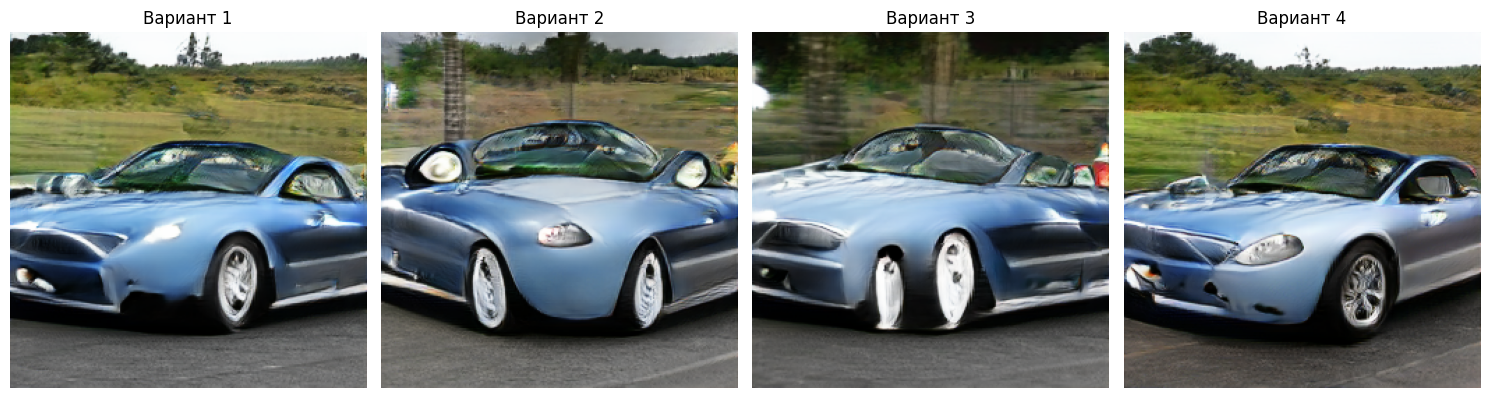

In [8]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import PIL.Image
from scipy.stats import truncnorm
import matplotlib.pyplot as plt

# 1. Загружаем модель BigGAN
model_url = 'https://tfhub.dev/deepmind/biggan-deep-256/1'
model = hub.load(model_url)
serving_fn = model.signatures['default']

# 2. Настройки генерации
car_class_index = 817   # Код класса "sports car" в ImageNet
truncation_value = 0.2  # Низкое значение, чтобы кузов меньше плыл
num_images = 4          # Количество генерируемых вариантов за один раз

fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
print(f"Генерация {num_images} вариантов автомобилей в режиме Eager Execution...")

for i in range(num_images):
    # 3. Формируем входные тензоры
    y_one_hot = tf.one_hot([car_class_index], 1000)

    z_noise = truncnorm.rvs(-2, 2, size=(1, 128)).astype(np.float32)
    z_noise = truncation_value * tf.convert_to_tensor(z_noise)

    inputs = {
        'z': z_noise,
        'y': y_one_hot,
        'truncation': tf.convert_to_tensor(truncation_value, dtype=tf.float32)
    }

    # 4. Генерируем изображение автомобиля
    output = serving_fn(**inputs)

    # 5. Получаем чистый NumPy-массив из выходного тензора
    image_numpy = output['default'].numpy()

    # 6. Постпроцессинг
    image_array = image_numpy[0]
    image_array = ((image_array + 1.0) * 127.5).clip(0, 255).astype(np.uint8)


    axes[i].imshow(image_array)
    axes[i].axis('off')
    axes[i].set_title(f"Вариант {i+1}")


plt.tight_layout()
plt.show()
